In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import json

from CMR_IA.utils import wmse

cmr.analysis.setup_notebook()

SAVEFIG = False
RUNCMR = False
SAVERES = False
if SAVERES and not RUNCMR:
    print("Warning: SAVERES is ignored when RUNCMR is False; existing results are loaded instead.")

## Load Stimuli and Semantic Matrix

In [2]:
# Load study and test data
df_study = pd.read_parquet("data/simu7_study.parquet")
df_test = pd.read_parquet("data/simu7_test.parquet")
df_study = df_study.loc[df_study.session < 500]
df_test = df_test.loc[df_test.session < 500]

In [3]:
# Inspect study data
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session
0,110,1083,BED,PLANT,0,0,0
1,1262,1627,SEAL,WRITER,1,0,0
2,738,1198,INMATE,ROBE,2,0,0
3,187,748,BUG,JAM,3,0,0
4,1423,1072,SWORD,PIN,4,0,0
...,...,...,...,...,...,...,...
95995,1507,755,TRIGGER,JELLY,7,15,499
95996,1635,616,ZEBRA,FURNITURE,8,15,499
95997,1313,175,SKATE,BRIEFCASE,9,15,499
95998,981,1438,ORCHESTRA,TAXI,10,15,499


In [4]:
# Inspect test data
df_test

,test_itemno,test_item,correct_ans,study_pos,test_dir,list,session
0,324,CLIPPERS,823,9,1,0,0
1,1347,SPARROW,1051,8,1,0,0
2,413,CROSS,524,7,0,0,0
3,812,LEOPARD,1323,5,0,0,0
4,110,BED,1083,0,0,0,0
...,...,...,...,...,...,...,...
63995,1297,SHRIMP,1053,3,0,15,499
63996,1205,ROOF,1156,1,0,15,499
63997,1436,TART,488,11,0,15,499
63998,755,JELLY,1507,7,1,15,499


In [5]:
# Load semantic matrix
sem_mat = np.load("../wordpools/ltp_FR_similarity_matrix.npy")

## Run CMR-IA

In [6]:
# Define parameters and load PSO results
params = cmr.load_params("7", fixed_params={"nitems_in_accumulator": 96})
params

{'beta_enc': 0.845814,
 'beta_rec': 0.083332,
 'beta_cue': 0.693018,
 'beta_rec_post': 0.224431,
 'beta_distract': 0.219932,
 'beta_enc_inpair': None,
 's_fc': 0.3027,
 's_cf': 0.346849,
 'phi_s': 1.496335,
 'phi_d': 0.013195,
 'psi_s': 0.0,
 'psi_c': 1.0,
 'd_assoc': None,
 'use_new_context': True,
 'use_flexible_thresh': True,
 'c_d': 0.0,
 'thresh_kernel_len': 10,
 'c_thresh_itm': 1.0,
 'c_thresh_assoc': 1.0,
 'c_s': 0.0,
 'thresh_sigma': 0.0,
 'recog_slope': 1.0,
 'kappa': 0.050411,
 'eta': 0.022039,
 'omega': 7.914679,
 'alpha': 0.961427,
 'lamb': 0.14727,
 'c_thresh': 0.364359,
 'ban_recall': None,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 96,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'gamma_fc': 0.776299,
 'gamma_cf': 0.488009}

In [7]:
# Run model or load saved results
if RUNCMR:
    df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)
    df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
    df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans
    if SAVERES:
        df_simu.to_parquet("data/simu7_result.parquet")
else:
    df_simu = pd.read_parquet("data/simu7_result.parquet")
df_simu

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [01:48<00:00,  4.59it/s]


CMR Time: 109.11928343772888


,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct
0,0,0,324,823,1430,0.893475,CLIPPERS,823,9,1,True
1,0,0,1347,1051,1630,0.901073,SPARROW,1051,8,1,True
2,0,0,413,812,2040,0.647148,CROSS,524,7,0,False
3,0,0,812,1323,1320,0.912797,LEOPARD,1323,5,0,True
4,0,0,110,679,2150,0.734301,BED,1083,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False
63996,499,15,1205,1156,1670,0.926118,ROOF,1156,1,0,True
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False


## Analysis

In [8]:
# Get the study list and study pos of response
sessions = np.unique(df_simu.session)
nlist = len(np.unique(df_simu.list))
resp_study_list = []
resp_study_pos = []
for sess in sessions:

    pres_words = df_study.loc[df_study.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy()
    pres_words = np.reshape(pres_words, (nlist, -1, 2))
    responses = df_simu.loc[df_simu.session == sess, "s_resp"]

    for r in responses:
        if r == -1 or r == -2:
            r_list = None
            r_pos = None
        else:
            r_list = np.where(pres_words == r)[0].item()
            r_pos = np.where(pres_words == r)[1].item()
        resp_study_list.append(r_list)
        resp_study_pos.append(r_pos)

df_simu["resp_study_list"] = resp_study_list
df_simu["resp_study_pos"] = resp_study_pos
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos
0,0,0,324,823,1430,0.893475,CLIPPERS,823,9,1,True,0.0,9.0
1,0,0,1347,1051,1630,0.901073,SPARROW,1051,8,1,True,0.0,8.0
2,0,0,413,812,2040,0.647148,CROSS,524,7,0,False,0.0,5.0
3,0,0,812,1323,1320,0.912797,LEOPARD,1323,5,0,True,0.0,5.0
4,0,0,110,679,2150,0.734301,BED,1083,0,0,False,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False,NaN,NaN
63996,499,15,1205,1156,1670,0.926118,ROOF,1156,1,0,True,15.0,1.0
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False,NaN,NaN
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False,NaN,NaN


In [9]:
# Get intrusion type
df_simu["list_lag"] = df_simu["resp_study_list"] - df_simu["list"]
df_simu["pos_lag"] = df_simu["resp_study_pos"] - df_simu["study_pos"]


def which_intrusion(x):
    x_list_lag = x["list_lag"]
    x_pos_lag = x["pos_lag"]

    if np.isnan(x_list_lag):
        return "NoResp"
    elif x_list_lag == 0 and x_pos_lag == 0:
        return "Correct"
    elif x_list_lag < 0:
        return "PLI"
    elif x_list_lag == 0 and x_pos_lag != 0:
        return "ILI"
    else:
        return np.nan


df_simu["intrusion_type"] = df_simu.apply(lambda x: which_intrusion(x), axis=1)
df_simu["intrusion_type"] = pd.Categorical(df_simu["intrusion_type"], categories=["NoResp", "Correct", "PLI", "ILI"])
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
0,0,0,324,823,1430,0.893475,CLIPPERS,823,9,1,True,0.0,9.0,0.0,0.0,Correct
1,0,0,1347,1051,1630,0.901073,SPARROW,1051,8,1,True,0.0,8.0,0.0,0.0,Correct
2,0,0,413,812,2040,0.647148,CROSS,524,7,0,False,0.0,5.0,0.0,-2.0,ILI
3,0,0,812,1323,1320,0.912797,LEOPARD,1323,5,0,True,0.0,5.0,0.0,0.0,Correct
4,0,0,110,679,2150,0.734301,BED,1083,0,0,False,0.0,6.0,0.0,6.0,ILI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False,NaN,NaN,NaN,NaN,NoResp
63996,499,15,1205,1156,1670,0.926118,ROOF,1156,1,0,True,15.0,1.0,0.0,0.0,Correct
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False,NaN,NaN,NaN,NaN,NoResp
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False,NaN,NaN,NaN,NaN,NoResp


In [10]:
# Clean list 1
df_simu = df_simu.query("list > 0").copy()
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
8,0,1,1141,1248,2200,0.897841,PUMP,1248,10,1,True,1.0,10.0,0.0,0.0,Correct
9,0,1,1540,232,1610,0.921971,UNIVERSE,232,9,0,True,1.0,9.0,0.0,0.0,Correct
10,0,1,528,1590,1320,0.919251,EMERALD,1590,8,1,True,1.0,8.0,0.0,0.0,Correct
11,0,1,506,1534,2070,0.906579,DUNE,1534,11,0,True,1.0,11.0,0.0,0.0,Correct
12,0,1,844,396,1300,0.914969,LOOP,396,5,1,True,1.0,5.0,0.0,0.0,Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False,NaN,NaN,NaN,NaN,NoResp
63996,499,15,1205,1156,1670,0.926118,ROOF,1156,1,0,True,15.0,1.0,0.0,0.0,Correct
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False,NaN,NaN,NaN,NaN,NoResp
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False,NaN,NaN,NaN,NaN,NoResp


In [11]:
# Check response types
df_simu.groupby("intrusion_type")["list"].count()

/tmp/ipykernel_627053/4088193204.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_simu.groupby("intrusion_type")["list"].count()


intrusion_type
NoResp     15039
Correct    41223
PLI         1055
ILI         2683
Name: list, dtype: int64

In [12]:
# Check no-response counts
df_simu.query("s_resp == -1").shape, df_simu.query("s_resp == -2").shape

((15039, 16), (0, 16))

### Overall Prob

In [13]:
# Count responses by session and intrusion type
df_cnt = df_simu.groupby(["session", "intrusion_type"]).s_resp.count().to_frame(name="count").reset_index()

/tmp/ipykernel_627053/2861543489.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cnt = df_simu.groupby(["session", "intrusion_type"]).s_resp.count().to_frame(name="count").reset_index()


In [14]:
# Check correct rate
df_cnt_correct = df_cnt.query("intrusion_type == 'Correct'").copy()
df_cnt_correct["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_correct["p"] = df_cnt_correct["count"] / df_cnt_correct["total"]
df_cnt_correct

,session,intrusion_type,count,total,p
1,0,Correct,80,120,0.666667
5,1,Correct,84,120,0.700000
9,2,Correct,86,120,0.716667
13,3,Correct,81,120,0.675000
17,4,Correct,81,120,0.675000
...,...,...,...,...,...
1981,495,Correct,87,120,0.725000
1985,496,Correct,73,120,0.608333
1989,497,Correct,77,120,0.641667
1993,498,Correct,81,120,0.675000


In [15]:
# Summarize correct rate
p_correct_mean = np.mean(df_cnt_correct["p"])
p_correct_mean

0.6870499999999999

In [16]:
# Check ILI rate
df_cnt_ILI = df_cnt.query("intrusion_type == 'ILI'").copy()
df_cnt_ILI["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_ILI["p"] = df_cnt_ILI["count"] / df_cnt_ILI["total"]
df_cnt_ILI

,session,intrusion_type,count,total,p
3,0,ILI,9,120,0.075000
7,1,ILI,8,120,0.066667
11,2,ILI,2,120,0.016667
15,3,ILI,4,120,0.033333
19,4,ILI,4,120,0.033333
...,...,...,...,...,...
1983,495,ILI,6,120,0.050000
1987,496,ILI,4,120,0.033333
1991,497,ILI,5,120,0.041667
1995,498,ILI,6,120,0.050000


In [17]:
# Summarize ILI rate
p_ILI_mean = np.mean(df_cnt_ILI["p"])
p_ILI_mean

0.04471666666666667

In [18]:
# Check PLI rate
df_cnt_PLI = df_cnt.query("intrusion_type == 'PLI'").copy()
df_cnt_PLI["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_PLI["p"] = df_cnt_PLI["count"] / df_cnt_PLI["total"]
df_cnt_PLI

,session,intrusion_type,count,total,p
2,0,PLI,1,120,0.008333
6,1,PLI,2,120,0.016667
10,2,PLI,4,120,0.033333
14,3,PLI,5,120,0.041667
18,4,PLI,1,120,0.008333
...,...,...,...,...,...
1982,495,PLI,1,120,0.008333
1986,496,PLI,2,120,0.016667
1990,497,PLI,2,120,0.016667
1994,498,PLI,4,120,0.033333


In [19]:
# Summarize PLI rate
p_PLI_mean = np.mean(df_cnt_PLI["p"])
p_PLI_mean

0.017583333333333333

### PLI

In [20]:
# Pick list > 5 and list_lag -5 to -1
df_PLI = df_simu.query("intrusion_type == 'PLI' and list > 5 and list_lag > -6").copy()
df_PLI["abs_list_lag"] = df_PLI["list_lag"].abs().astype(int)
df_PLI["abs_list_lag"] = pd.Categorical(df_PLI["abs_list_lag"], categories=[1, 2, 3, 4, 5], ordered=True)
df_PLI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type,abs_list_lag
52,0,6,420,762,3110,0.761881,CUBE,1488,9,0,False,4.0,3.0,-2.0,-6.0,PLI,2
195,1,8,953,798,4870,0.738394,NIGHTGOWN,1500,2,1,False,7.0,0.0,-1.0,-2.0,PLI,1
242,1,14,1355,1357,3730,0.766306,SPONGE,218,10,1,False,13.0,5.0,-1.0,-5.0,PLI,1
344,2,11,443,778,2810,0.689250,DECK,196,6,0,False,9.0,0.0,-2.0,-6.0,PLI,2
348,2,11,1578,1514,2050,0.728104,WAGON,237,3,1,False,10.0,0.0,-1.0,-3.0,PLI,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63555,496,8,1367,881,4850,0.733006,STAIRS,540,0,0,False,4.0,4.0,-4.0,4.0,PLI,4
63582,496,11,742,490,3670,0.726977,INTESTINE,1621,4,1,False,7.0,1.0,-4.0,-3.0,PLI,4
63837,498,11,15,780,3250,0.749268,ALLEY,735,1,1,False,6.0,6.0,-5.0,5.0,PLI,5
63849,498,13,483,834,1670,0.824600,DOLPHIN,549,1,0,False,8.0,0.0,-5.0,-1.0,PLI,5


In [21]:
# Session-wise, count PLI
df_PLI_sess = df_PLI.groupby(["session"]).test_item.count().to_frame(name="PLI_cnt_sess").reset_index()
df_PLI_sess

,session,PLI_cnt_sess
0,0,1
1,1,2
2,2,3
3,3,4
4,5,1
...,...,...
304,493,1
305,494,1
306,495,1
307,496,2


In [22]:
# Session-wise, count PLI by list_lag
df_PLI_sess_lag = df_PLI.groupby(["session", "abs_list_lag"]).test_item.count().to_frame(name="PLI_cnt").reset_index()
df_PLI_sess_lag

/tmp/ipykernel_627053/768046930.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_PLI_sess_lag = df_PLI.groupby(["session", "abs_list_lag"]).test_item.count().to_frame(name="PLI_cnt").reset_index()


,session,abs_list_lag,PLI_cnt
0,0,1,0
1,0,2,1
2,0,3,0
3,0,4,0
4,0,5,0
...,...,...,...
1540,498,1,0
1541,498,2,0
1542,498,3,0
1543,498,4,0


In [23]:
# Calculate PLI probability
df_PLI_sess_lag = pd.merge(df_PLI_sess_lag, df_PLI_sess, on="session")
df_PLI_sess_lag["PLI_prob"] = df_PLI_sess_lag["PLI_cnt"] / df_PLI_sess_lag["PLI_cnt_sess"]
df_PLI_sess_lag

,session,abs_list_lag,PLI_cnt,PLI_cnt_sess,PLI_prob
0,0,1,0,1,0.0
1,0,2,1,1,1.0
2,0,3,0,1,0.0
3,0,4,0,1,0.0
4,0,5,0,1,0.0
...,...,...,...,...,...
1540,498,1,0,3,0.0
1541,498,2,0,3,0.0
1542,498,3,0,3,0.0
1543,498,4,0,3,0.0


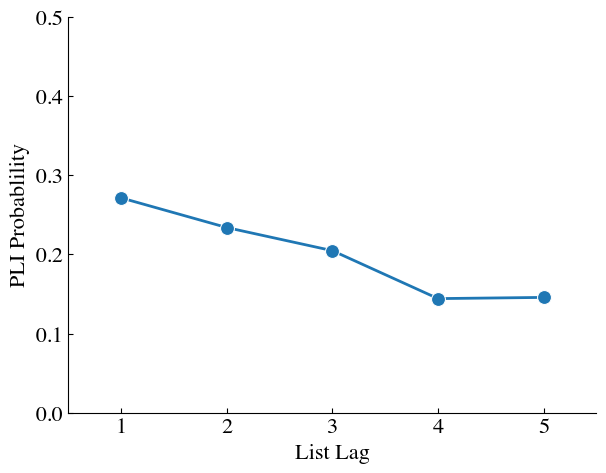

In [24]:
# Plot PLI probability by list lag
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_PLI_sess_lag, x="abs_list_lag", y="PLI_prob", linewidth=2, marker="o", markersize=10, errorbar=None)
plt.ylim([0, 0.5])
plt.xlim([0.5, 5.5])
plt.xticks(ticks=np.arange(1, 6))
plt.xlabel("List Lag")
plt.ylabel("PLI Probablility")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu7_PLI.pdf")
plt.show()

### ILI

In [25]:
# Pick out ILI
df_ILI = df_simu.query("intrusion_type == 'ILI'").copy()
df_ILI["pos_lag"] = df_ILI["pos_lag"].astype(int)
df_ILI["pos_lag"] = pd.Categorical(df_ILI["pos_lag"], categories=np.concatenate([np.arange(-11, 0), np.arange(1, 12)]), ordered=True)
df_ILI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
16,0,2,173,492,1970,0.861439,BRIDE,414,10,0,False,2.0,11.0,0.0,1,ILI
20,0,2,1399,1016,2940,0.646449,SUBURB,142,3,1,False,2.0,2.0,0.0,-1,ILI
25,0,3,621,266,3960,0.783633,GARAGE,1202,10,1,False,3.0,11.0,0.0,1,ILI
27,0,3,245,911,3130,0.718455,CARNIVAL,1410,6,0,False,3.0,5.0,0.0,-1,ILI
29,0,3,659,429,4030,0.769887,GRAVEL,266,11,0,False,3.0,1.0,0.0,-10,ILI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63887,499,1,1583,153,1870,0.739303,WALLET,593,2,1,False,1.0,6.0,0.0,4,ILI
63888,499,2,284,315,3960,0.742116,CHECK,1399,2,0,False,2.0,11.0,0.0,9,ILI
63900,499,3,1133,866,3050,0.727807,PROTRACTOR,1310,7,1,False,3.0,5.0,0.0,-2,ILI
63920,499,6,475,1638,2880,0.836152,DISHWASHER,799,9,0,False,6.0,11.0,0.0,2,ILI


In [26]:
# Session-wise, calculate ILI probability for each lag
def get_ILI_prob(df_tmp):

    # Get possible ILI count
    possible_ILI_cnt = {}
    for pair_pos in df_tmp.study_pos:
        l_bound = -pair_pos
        r_bound = 11 - pair_pos
        for i in np.arange(l_bound, r_bound + 1):
            if i in possible_ILI_cnt:
                possible_ILI_cnt[i] += 1
            else:
                possible_ILI_cnt[i] = 1

    # Get ILI count
    df_tmp_lag = df_tmp.groupby("pos_lag", observed=False)["test_item"].count().to_frame(name="ILI_cnt")

    # Merge possible ILI count
    df_tmp_lag["possible_ILI_cnt"] = df_tmp_lag.index.map(possible_ILI_cnt).astype(float)
    df_tmp_lag["ILI_prob"] = df_tmp_lag["ILI_cnt"] / df_tmp_lag["possible_ILI_cnt"]

    return df_tmp_lag


df_ILI_sess_lag = df_ILI.groupby("session").apply(get_ILI_prob, include_groups=False).reset_index()
df_ILI_sess_lag["pos_lag"] = df_ILI_sess_lag["pos_lag"].astype(int)
df_ILI_sess_lag = df_ILI_sess_lag.query("pos_lag > -6 and pos_lag < 6").copy()
df_ILI_sess_lag

,session,pos_lag,ILI_cnt,possible_ILI_cnt,ILI_prob
6,0,-5,1,7.0,0.142857
7,0,-4,0,7.0,0.000000
8,0,-3,0,8.0,0.000000
9,0,-2,0,8.0,0.000000
10,0,-1,3,9.0,0.333333
...,...,...,...,...,...
10967,499,1,0,5.0,0.000000
10968,499,2,1,5.0,0.200000
10969,499,3,0,4.0,0.000000
10970,499,4,1,4.0,0.250000


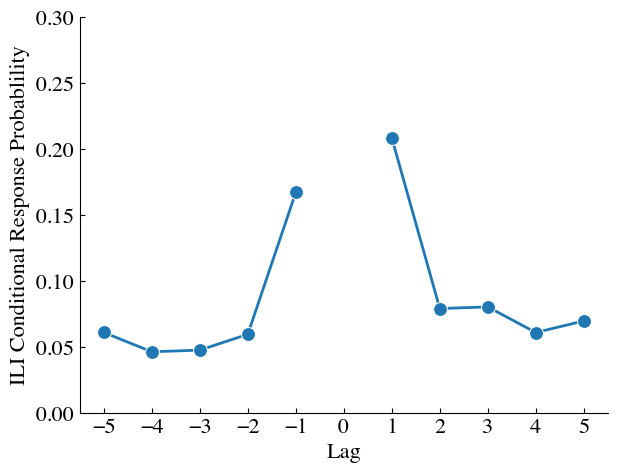

In [27]:
# Plot ILI probability by position lag
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

df_ILI_sess_lag["pos_lag"] = df_ILI_sess_lag["pos_lag"].astype(int)
sns.lineplot(data=df_ILI_sess_lag.query("-6 < pos_lag < 0"), x="pos_lag", y="ILI_prob", linewidth=2, marker="o", markersize=10, color="C0", errorbar=None)
sns.lineplot(data=df_ILI_sess_lag.query("0 < pos_lag < 6"), x="pos_lag", y="ILI_prob", linewidth=2, marker="o", markersize=10, color="C0", errorbar=None)
plt.ylim([0, 0.3])
plt.xticks(ticks=np.arange(-5, 6))
plt.xlabel("Lag")
plt.ylabel("ILI Conditional Response Probablility")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("figures/simu7_ILI.pdf")
plt.show()

## Err Check

In [28]:
# Aggregate mean PLI and ILI probabilities by lag
lag_PLI_mean = df_PLI_sess_lag.groupby("abs_list_lag").PLI_prob.mean().values
df_ILI_sess_lag["pos_lag_int"] = df_ILI_sess_lag["pos_lag"].astype(int)  # avoid nan from category vairables
lag_ILI_mean = df_ILI_sess_lag.groupby("pos_lag_int").ILI_prob.mean().values
lag_PLI_mean, lag_ILI_mean

/tmp/ipykernel_627053/4187414907.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lag_PLI_mean = df_PLI_sess_lag.groupby("abs_list_lag").PLI_prob.mean().values


(array([0.27135922, 0.23392665, 0.20474649, 0.14422869, 0.14573894]),
 array([0.06107224, 0.04644092, 0.04769849, 0.05969954, 0.16721134,
        0.20850482, 0.07919067, 0.08043619, 0.06103963, 0.06980925]))

In [29]:
# Check PLI monotonicity constraint
np.cov(np.arange(5), lag_PLI_mean)[0, 1] >= 0

False

In [30]:
# Check ILI monotonicity constraint
np.any(np.diff(lag_ILI_mean[:5]) <= 0), np.any(np.diff(lag_ILI_mean[5:]) >= 0)

(True, True)

In [31]:
# Load ground truth
with open("data/simu7_gt.json") as f:
    gt = json.load(f)
p_correct_mean_gt = np.array(gt["p_correct_mean"])
p_correct_se_gt = np.array(gt["p_correct_se"])
p_PLI_mean_gt = np.array(gt["p_PLI_mean"])
p_PLI_se_gt = np.array(gt["p_PLI_se"])
p_ILI_mean_gt = np.array(gt["p_ILI_mean"])
p_ILI_se_gt = np.array(gt["p_ILI_se"])
lag_PLI_mean_gt = np.array(gt["lag_PLI_mean"])
lag_PLI_se_gt = np.array(gt["lag_PLI_se"])
lag_ILI_mean_gt = np.array(gt["lag_ILI_mean"])
lag_ILI_se_gt = np.array(gt["lag_ILI_se"])

In [32]:
# Inspect ground truth lag means
lag_PLI_mean_gt, lag_ILI_mean_gt

(array([0.32678571, 0.24033447, 0.16269841, 0.19515306, 0.07502834]),
 array([0.04853509, 0.08652118, 0.08350867, 0.09478323, 0.1486024 ,
        0.21154655, 0.08574898, 0.10563333, 0.08867651, 0.0508634 ]))

In [33]:
# Compute weighted mean squared error
wls_p_correct = wmse(p_correct_mean_gt, p_correct_mean, p_correct_se_gt)
wls_p_PLI = wmse(p_PLI_mean_gt, p_PLI_mean, p_PLI_se_gt)
wls_p_ILI = wmse(p_ILI_mean_gt, p_ILI_mean, p_ILI_se_gt)
wls_lag_PLI = wmse(lag_PLI_mean_gt, lag_PLI_mean, lag_PLI_se_gt) / len(lag_PLI_mean_gt)
wls_lag_ILI = wmse(lag_ILI_mean_gt, lag_ILI_mean, lag_ILI_se_gt) / len(lag_ILI_mean_gt)
err = wls_p_correct + wls_p_PLI + wls_p_ILI + wls_lag_PLI + wls_lag_ILI
err

0.08019488683423623

In [34]:
# Print PLI and ILI lag WLS errors
wls_lag_PLI, wls_lag_ILI

(0.04120791508030165, 0.03567927250836574)